#### Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load your clean data
df = pd.read_csv("cleaned_product_info.csv")

# 2. CREATE THE TARGET VARIABLE (The Classes)
# Logic: We use Quantiles (33% split) to ensure balanced classes.
# This prevents the model from just guessing "High" for everything.

# Calculate the exact cutoffs based on the data
t1 = df['rating'].quantile(0.33) # The bottom 33% cutoff
t2 = df['rating'].quantile(0.66) # The top 33% cutoff

print(f"Dynamic Thresholds found: Low < {t1:.2f}, High > {t2:.2f}")

def classify_rating(r):
    if r <= t1:
        return 0 # Low (Bottom 33% of products)
    elif r <= t2:
        return 1 # Medium (Middle 33% of products)
    else:
        return 2 # High (Top 33% of products)

df['rating_class'] = df['rating'].apply(classify_rating)

# Verify the balance
print("Class Distribution (Should be roughly equal):")
print(df['rating_class'].value_counts())

# 3. SELECT FEATURES (The inputs for the simulator)
# We drop 'rating' (the answer) and identifiers like 'product_id'
features = ['brand_name', 'price_usd', 'primary_category', 'secondary_category', 'tertiary_category', 'online_only', 'limited_edition', 'new', 'sephora_exclusive']
X = df[features].copy()
y = df['rating_class']

# 4. ENCODE CATEGORICAL VARIABLES
# We need to save these encoders to use them in the Simulator later!
label_encoders = {}
categorical_cols = ['brand_name', 'primary_category', 'secondary_category', 'tertiary_category']

for col in categorical_cols:
    le = LabelEncoder()
    # Handle unknown values in future by fitting on string type
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Save the encoder for later use

print("\nData Encoded successfully.")

# 5. SPLIT THE DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")
print("\n✅ Task 1 Complete: Data is ready for training.")

Dynamic Thresholds found: Low < 4.11, High > 4.44
Class Distribution (Should be roughly equal):
rating_class
2    2257
1    2191
0    2191
Name: count, dtype: int64

Data Encoded successfully.
Training Data Shape: (5311, 9)
Testing Data Shape: (1328, 9)

✅ Task 1 Complete: Data is ready for training.


#### Model Training

Training the model... (This may take a moment)


✅ Training Complete!

Model Accuracy: 46.46%

Classification Report:
              precision    recall  f1-score   support

         Low       0.47      0.47      0.47       438
      Medium       0.39      0.39      0.39       438
        High       0.54      0.53      0.53       452

    accuracy                           0.46      1328
   macro avg       0.46      0.46      0.46      1328
weighted avg       0.47      0.46      0.46      1328



C:\Users\User\AppData\Local\Temp\ipykernel_12128\3257055950.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


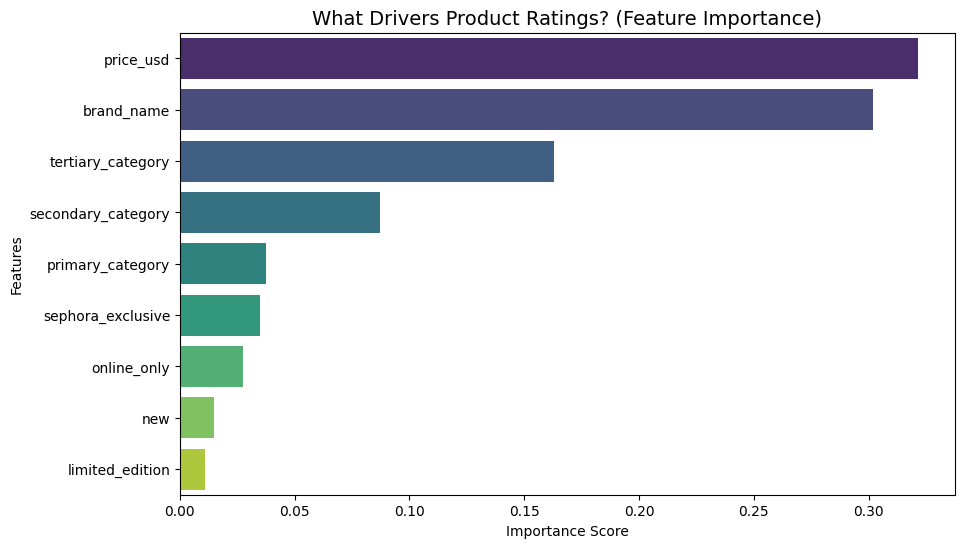


Top Factors influencing Rating:
              Feature  Importance
1           price_usd    0.321558
0          brand_name    0.301891
4   tertiary_category    0.163089
3  secondary_category    0.087258
2    primary_category    0.037563


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Model
# n_estimators=100 means we create 100 "Decision Trees" to vote on the answer
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model
print("Training the model... (This may take a moment)")
rf_model.fit(X_train, y_train)
print("✅ Training Complete!")

# 3. Evaluate the Performance
# We test the model on the 20% of data it has NEVER seen before
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2%}")

# Print the Detailed Report
# Precision = How distinct the guesses were
# Recall = How many of the actual High/Med/Low it found
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

# 4. Feature Importance Visualization
# This shows exactly which factors the model is using to make decisions
importances = rf_model.feature_importances_
feature_names = X.columns

# Organize into a neat table
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title("What Drivers Product Ratings? (Feature Importance)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

print("\nTop Factors influencing Rating:")
print(feature_imp_df.head())

In [20]:
def predict_product_success(brand, price, primary_cat, secondary_cat, tertiary_cat, is_new=0, is_exclusive=0):
    """
    Simulates a new product launch and predicts its market reception.
    """
    
    # 1. Prepare the Input Data
    # We must format the single input row exactly like the training data
    input_data = pd.DataFrame({
        'brand_name': [brand],
        'price_usd': [price],
        'primary_category': [primary_cat],
        'secondary_category': [secondary_cat],
        'tertiary_category': [tertiary_cat],
        'online_only': [0],      # Default assumption
        'limited_edition': [0],  # Default assumption
        'new': [is_new],
        'sephora_exclusive': [is_exclusive]
    })

    # 2. Handle Categorical Encoding
    # We use the encoders we saved earlier to turn text into numbers
    # If the model has never seen the brand, we map it to "Unknown" (handling errors)
    for col in ['brand_name', 'primary_category', 'secondary_category', 'tertiary_category']:
        encoder = label_encoders[col]
        input_val = input_data[col].iloc[0]
        
        # Check if we know this category/brand
        if input_val in encoder.classes_:
            input_data[col] = encoder.transform([input_val])
        else:
            # Fallback: Assign to the most common category (mode) or 0
            # Ideally we would have an 'Other' class, but for now we pick the first class
            print(f"⚠️ Warning: '{input_val}' is a new {col}. The model might be less accurate.")
            input_data[col] = 0 

    # 3. Make the Prediction
    prediction_class = rf_model.predict(input_data)[0]
    probability = rf_model.predict_proba(input_data).max()
    
    # 4. Translate Result
    labels = {0: "Low (Avoid Launch)", 1: "Medium (Risk)", 2: "High (Safe Bet)"}
    result = labels[prediction_class]
    
    print(f"--- 🔮 Market Simulation: {brand} {tertiary_cat} ---")
    print(f"Price Point: ${price}")
    print(f"Prediction: {result}")
    print(f"Confidence: {probability:.1%}\n")
    
    return result

# --- TEST SCENARIOS ---
# Let's test the simulator with 3 hypothetical products!

# Scenario A: A Cheap Lipstick from a High-End Brand (Unusual)
predict_product_success("Dior", 15.00, "Makeup", "Lips", "Lipstick")

# Scenario B: An Expensive Face Cream from a Budget Brand (Risky)
predict_product_success("Sephora Collection", 120.00, "Skincare", "Moisturizers", "Moisturizers")

# Scenario C: A Mid-Range Perfume (Standard)
predict_product_success("Chanel", 95.00, "Fragrance", "Women", "Perfume")

⚠️ Warning: 'Lips' is a new secondary_category. The model might be less accurate.
--- 🔮 Market Simulation: Dior Lipstick ---
Price Point: $15.0
Prediction: Low (Avoid Launch)
Confidence: 73.0%

--- 🔮 Market Simulation: Sephora Collection Moisturizers ---
Price Point: $120.0
Prediction: Low (Avoid Launch)
Confidence: 60.2%

--- 🔮 Market Simulation: Chanel Perfume ---
Price Point: $95.0
Prediction: High (Safe Bet)
Confidence: 85.7%



'High (Safe Bet)'

In [17]:
import joblib

# Save the trained model
joblib.dump(rf_model, 'rf_model.pkl')

# Save the label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')

print("✅ Model and Encoders saved!")

✅ Model and Encoders saved!
